In [1]:
!pip install geopandas shapely folium branca -q

In [2]:
import os
import json
import warnings

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely import wkt
from folium.plugins import Fullscreen, MiniMap, Search

warnings.filterwarnings("ignore")

In [3]:
input_path = "/content/Parks_Properties_20260628.csv"

In [4]:
df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (2059, 33)

Column names:
['ACQUISITIONDATE', 'ACRES', 'ADDRESS', 'BOROUGH', 'CLASS', 'COMMUNITYBOARD', 'COUNCILDISTRICT', 'DEPARTMENT', 'GISOBJID', 'GISPROPNUM', 'GlobalID', 'JURISDICTION', 'LOCATION', 'MAPPED', 'NAME311', 'NYS_ASSEMBLY', 'NYS_SENATE', 'OBJECTID', 'OMPPROPID', 'PARENTID', 'PERMIT', 'PERMITDISTRICT', 'PERMITPARENT', 'PIP_RATABLE', 'PRECINCT', 'RETIRED', 'SIGNNAME', 'SUBCATEGORY', 'TYPECATEGORY', 'US_CONGRESS', 'WATERFRONT', 'ZIPCODE', 'multipolygon']


,ACQUISITIONDATE,ACRES,ADDRESS,BOROUGH,CLASS,COMMUNITYBOARD,COUNCILDISTRICT,DEPARTMENT,GISOBJID,GISPROPNUM,...,PIP_RATABLE,PRECINCT,RETIRED,SIGNNAME,SUBCATEGORY,TYPECATEGORY,US_CONGRESS,WATERFRONT,ZIPCODE,multipolygon
0,1934 Feb 28 12:00:00 AM,0.403,532 EAST 12 STREET,M,PARK,103,2,M-03,"100,004,130",M113,...,True,9,False,Joseph C. Sauer Park,Neighborhood Plgd,Neighborhood Park,10,False,10009,MULTIPOLYGON (((-73.97937993443009 40.72811989...
1,NaN,0.2,NaN,Q,PARK,408,24,Q-08,"100,000,404",Q084B,...,True,107,False,Tepper Triangle,Sitting Area/Triangle/Mall,Triangle/Plaza,6,False,11432,MULTIPOLYGON (((-73.79124791809534 40.71881510...
2,1948 Jan 29 12:00:00 AM,1.534,255 PARKINSON AVENUE,R,PARK,502,50,R-02B,"100,004,659",R063,...,True,122,False,Old Town Playground,JOP,Playground,11,False,10305,MULTIPOLYGON (((-74.08082911468377 40.59514394...
3,1955 Jul 21 12:00:00 AM,0.056,294 6 AVENUE,M,PARK,102,2,M-02,"100,004,867",M125A,...,True,6,False,Minetta Green,Sitting Area/Triangle/Mall,Triangle/Plaza,10,False,10012,MULTIPOLYGON (((-74.00154712711851 40.73023996...
4,1934 Jun 08 12:00:00 AM,0.763,2 2 AVENUE,M,PARK,103,2,M-03,"100,004,795",M124,...,True,9,False,First Park,Neighborhood Plgd,Neighborhood Park,10,False,10003,MULTIPOLYGON (((-73.9904178720097 40.724017527...


In [5]:
selected_columns = [
    "GISPROPNUM",
    "SIGNNAME",
    "NAME311",
    "BOROUGH",
    "ADDRESS",
    "LOCATION",
    "ACRES",
    "TYPECATEGORY",
    "SUBCATEGORY",
    "WATERFRONT",
    "ZIPCODE",
    "COMMUNITYBOARD",
    "COUNCILDISTRICT",
    "JURISDICTION",
    "RETIRED",
    "multipolygon"
]

parks = df[selected_columns].copy()

print("Selected dataset shape:", parks.shape)
display(parks.head())

Selected dataset shape: (2059, 16)


,GISPROPNUM,SIGNNAME,NAME311,BOROUGH,ADDRESS,LOCATION,ACRES,TYPECATEGORY,SUBCATEGORY,WATERFRONT,ZIPCODE,COMMUNITYBOARD,COUNCILDISTRICT,JURISDICTION,RETIRED,multipolygon
0,M113,Joseph C. Sauer Park,Joseph C. Sauer Park,M,532 EAST 12 STREET,E. 12 St. bet. Ave. A and Ave. B,0.403,Neighborhood Park,Neighborhood Plgd,False,10009,103,2,DPR,False,MULTIPOLYGON (((-73.97937993443009 40.72811989...
1,Q084B,Tepper Triangle,Tepper Triangle,Q,NaN,"GCP Service Rd. South, 173 St., Homelawn St.",0.2,Triangle/Plaza,Sitting Area/Triangle/Mall,False,11432,408,24,DPR,False,MULTIPOLYGON (((-73.79124791809534 40.71881510...
2,R063,Old Town Playground,Old Town Playground,R,255 PARKINSON AVENUE,Parkinson Ave. at Kramer St.,1.534,Playground,JOP,False,10305,502,50,DPR,False,MULTIPOLYGON (((-74.08082911468377 40.59514394...
3,M125A,Minetta Green,Minetta Green,M,294 6 AVENUE,S/e Corner Minetta Lane and Ave. of Americas,0.056,Triangle/Plaza,Sitting Area/Triangle/Mall,False,10012,102,2,DPR,False,MULTIPOLYGON (((-74.00154712711851 40.73023996...
4,M124,First Park,First Park,M,2 2 AVENUE,"Houston St., E. 1 St., 1 Ave.",0.763,Neighborhood Park,Neighborhood Plgd,False,10003,103,2,DPR,False,MULTIPOLYGON (((-73.9904178720097 40.724017527...


data cleaning

In [6]:
# Standardize column names
parks.columns = parks.columns.str.strip().str.upper()

# Borough code mapping
borough_mapping = {
    "M": "Manhattan",
    "B": "Brooklyn",
    "Q": "Queens",
    "R": "Staten Island",
    "X": "Bronx"
}

parks["BOROUGH"] = (
    parks["BOROUGH"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace(borough_mapping)
)

# Clean text columns
text_columns = [
    "GISPROPNUM",
    "SIGNNAME",
    "NAME311",
    "ADDRESS",
    "LOCATION",
    "TYPECATEGORY",
    "SUBCATEGORY",
    "ZIPCODE",
    "COMMUNITYBOARD",
    "COUNCILDISTRICT",
    "JURISDICTION"
]

for column in text_columns:
    parks[column] = (
        parks[column]
        .astype("string")
        .str.strip()
        .replace({
            "": pd.NA,
            "nan": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA
        })
    )

# Convert ACRES to numeric
parks["ACRES"] = pd.to_numeric(
    parks["ACRES"],
    errors="coerce"
)

# Standardize Boolean values
def clean_boolean(value):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().lower()

    if value in ["true", "yes", "1", "y"]:
        return True
    elif value in ["false", "no", "0", "n"]:
        return False

    return pd.NA


parks["WATERFRONT"] = parks["WATERFRONT"].apply(clean_boolean)
parks["RETIRED"] = parks["RETIRED"].apply(clean_boolean)

# Create one final park name
parks["PARK_NAME"] = parks["SIGNNAME"].fillna(parks["NAME311"])
parks["PARK_NAME"] = parks["PARK_NAME"].fillna("Unnamed Park")

# Remove retired properties
parks = parks[
    (parks["RETIRED"] == False) |
    (parks["RETIRED"].isna())
].copy()

# Remove records without geometry
parks = parks.dropna(subset=["MULTIPOLYGON"])

# Remove duplicates
parks = parks.drop_duplicates(
    subset=["GISPROPNUM", "PARK_NAME", "BOROUGH"]
).reset_index(drop=True)

print("Cleaned records:", len(parks))
display(parks.head())

Cleaned records: 2058


,GISPROPNUM,SIGNNAME,NAME311,BOROUGH,ADDRESS,LOCATION,ACRES,TYPECATEGORY,SUBCATEGORY,WATERFRONT,ZIPCODE,COMMUNITYBOARD,COUNCILDISTRICT,JURISDICTION,RETIRED,MULTIPOLYGON,PARK_NAME
0,M113,Joseph C. Sauer Park,Joseph C. Sauer Park,Manhattan,532 EAST 12 STREET,E. 12 St. bet. Ave. A and Ave. B,0.403,Neighborhood Park,Neighborhood Plgd,False,10009,103,2,DPR,False,MULTIPOLYGON (((-73.97937993443009 40.72811989...,Joseph C. Sauer Park
1,Q084B,Tepper Triangle,Tepper Triangle,Queens,<NA>,"GCP Service Rd. South, 173 St., Homelawn St.",0.200,Triangle/Plaza,Sitting Area/Triangle/Mall,False,11432,408,24,DPR,False,MULTIPOLYGON (((-73.79124791809534 40.71881510...,Tepper Triangle
2,R063,Old Town Playground,Old Town Playground,Staten Island,255 PARKINSON AVENUE,Parkinson Ave. at Kramer St.,1.534,Playground,JOP,False,10305,502,50,DPR,False,MULTIPOLYGON (((-74.08082911468377 40.59514394...,Old Town Playground
3,M125A,Minetta Green,Minetta Green,Manhattan,294 6 AVENUE,S/e Corner Minetta Lane and Ave. of Americas,0.056,Triangle/Plaza,Sitting Area/Triangle/Mall,False,10012,102,2,DPR,False,MULTIPOLYGON (((-74.00154712711851 40.73023996...,Minetta Green
4,M124,First Park,First Park,Manhattan,2 2 AVENUE,"Houston St., E. 1 St., 1 Ave.",0.763,Neighborhood Park,Neighborhood Plgd,False,10003,103,2,DPR,False,MULTIPOLYGON (((-73.9904178720097 40.724017527...,First Park


Convert the multipolygon column to spatial geometry

In [7]:
def convert_wkt(value):
    try:
        return wkt.loads(value)
    except Exception:
        return None


parks["GEOMETRY"] = parks["MULTIPOLYGON"].apply(convert_wkt)

gdf = gpd.GeoDataFrame(
    parks,
    geometry="GEOMETRY",
    crs="EPSG:4326"
)

# Remove missing and empty geometry
gdf = gdf[
    gdf.geometry.notna() &
    ~gdf.geometry.is_empty
].copy()

# Repair invalid geometry when possible
gdf["GEOMETRY"] = gdf.geometry.buffer(0)

gdf = gdf[
    gdf.geometry.notna() &
    ~gdf.geometry.is_empty &
    gdf.geometry.is_valid
].copy()

print("Valid spatial records:", len(gdf))
print("Coordinate reference system:", gdf.crs)

Valid spatial records: 2058
Coordinate reference system: EPSG:4326


Calculate park center points

In [8]:
# Use NYC projected coordinate system for accurate centroid calculation
projected_gdf = gdf.to_crs("EPSG:2263")

projected_gdf["CENTROID_GEOMETRY"] = projected_gdf.geometry.centroid

centroid_gdf = projected_gdf.set_geometry(
    "CENTROID_GEOMETRY"
).to_crs("EPSG:4326")

gdf["LATITUDE"] = centroid_gdf.geometry.y.values
gdf["LONGITUDE"] = centroid_gdf.geometry.x.values

display(
    gdf[
        ["PARK_NAME", "BOROUGH", "LATITUDE", "LONGITUDE"]
    ].head()
)

,PARK_NAME,BOROUGH,LATITUDE,LONGITUDE
0,Joseph C. Sauer Park,Manhattan,40.728173,-73.979735
1,Tepper Triangle,Queens,40.718724,-73.791622
2,Old Town Playground,Staten Island,40.595395,-74.081361
3,Minetta Green,Manhattan,40.730319,-74.001609
4,First Park,Manhattan,40.723518,-73.989639


Create summary

In [9]:
summary = {
    "Total park properties": len(gdf),
    "Total mapped acres": round(gdf["ACRES"].sum(), 2),
    "Average park size": round(gdf["ACRES"].mean(), 2),
    "Median park size": round(gdf["ACRES"].median(), 2),
    "Largest park size": round(gdf["ACRES"].max(), 2)
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total park properties,2058.00
1,Total mapped acres,26546.75
2,Average park size,12.91
3,Median park size,0.70
4,Largest park size,953.07


In [10]:
parks_by_borough = (
    gdf.groupby("BOROUGH")
    .size()
    .reset_index(name="NUMBER_OF_PARKS")
    .sort_values("NUMBER_OF_PARKS", ascending=False)
)

display(parks_by_borough)

,BOROUGH,NUMBER_OF_PARKS
1,Brooklyn,628
3,Queens,476
0,Bronx,398
2,Manhattan,395
4,Staten Island,161


In [11]:
acres_by_borough = (
    gdf.groupby("BOROUGH", dropna=False)["ACRES"]
    .sum()
    .reset_index()
    .sort_values("ACRES", ascending=False)
)

acres_by_borough["ACRES"] = acres_by_borough["ACRES"].round(2)

display(acres_by_borough)

,BOROUGH,ACRES
4,Staten Island,7717.10
3,Queens,7715.61
1,Brooklyn,4862.93
0,Bronx,3376.28
2,Manhattan,2874.83


In [12]:
largest_parks = (
    gdf[
        ["PARK_NAME", "BOROUGH", "TYPECATEGORY", "ACRES"]
    ]
    .dropna(subset=["ACRES"])
    .sort_values("ACRES", ascending=False)
    .head(15)
)

display(largest_parks)

,PARK_NAME,BOROUGH,TYPECATEGORY,ACRES
2016,Freshkills Park,Staten Island,Community Park,953.065
1689,Flushing Meadows Corona Park,Queens,Flagship Park,870.761
672,Central Park,Manhattan,Flagship Park,840.010
642,Marine Park,Brooklyn,Community Park,800.000
341,LaTourette Park & Golf Course,Staten Island,Flagship Park,760.790
1544,Belt Parkway/Shore Parkway,Brooklyn,Parkway,760.430
2011,Bronx Park,Bronx,Flagship Park,718.373
688,Franklin D. Roosevelt Boardwalk and Beach,Staten Island,Waterfront Facility,644.350
1863,Alley Pond Park,Queens,Flagship Park,635.514
2030,Prospect Park,Brooklyn,Flagship Park,526.250


In [13]:
park_categories = (
    gdf["TYPECATEGORY"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

park_categories.columns = [
    "TYPECATEGORY",
    "NUMBER_OF_PARKS"
]

display(park_categories.head(15))

,TYPECATEGORY,NUMBER_OF_PARKS
0,Triangle/Plaza,355
1,Garden,350
2,Neighborhood Park,295
3,Jointly Operated Playground,261
4,Playground,249
5,Community Park,113
6,Nature Area,90
7,Recreational Field/Courts,75
8,Strip,67
9,Undeveloped,37


In [14]:
output_folder = "/content/nyc_parks_project"
chart_folder = os.path.join(output_folder, "charts")
data_folder = os.path.join(output_folder, "data")
map_folder = os.path.join(output_folder, "map")

os.makedirs(chart_folder, exist_ok=True)
os.makedirs(data_folder, exist_ok=True)
os.makedirs(map_folder, exist_ok=True)

print("Output folder created:", output_folder)

Output folder created: /content/nyc_parks_project


Chart: number of parks by borough

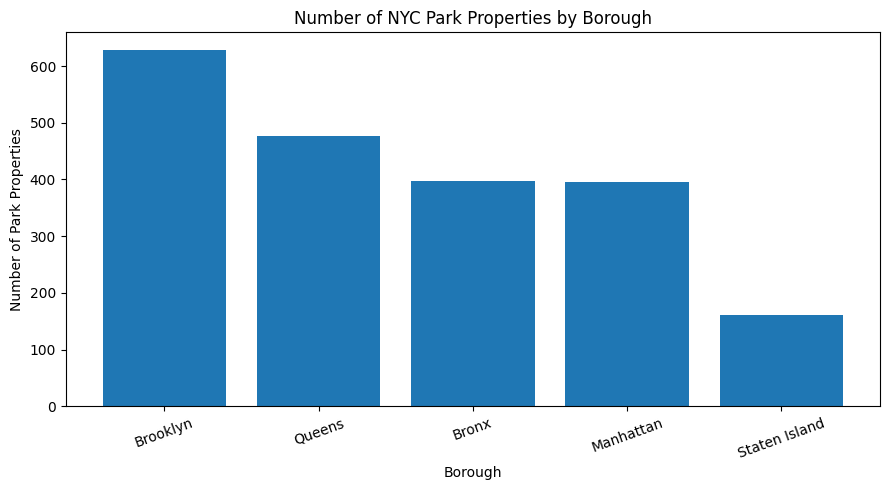

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    parks_by_borough["BOROUGH"],
    parks_by_borough["NUMBER_OF_PARKS"]
)

plt.title("Number of NYC Park Properties by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Park Properties")
plt.xticks(rotation=20)
plt.tight_layout()

borough_chart_path = os.path.join(
    chart_folder,
    "parks_by_borough.png"
)

plt.savefig(
    borough_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Chart: total acreage by borough

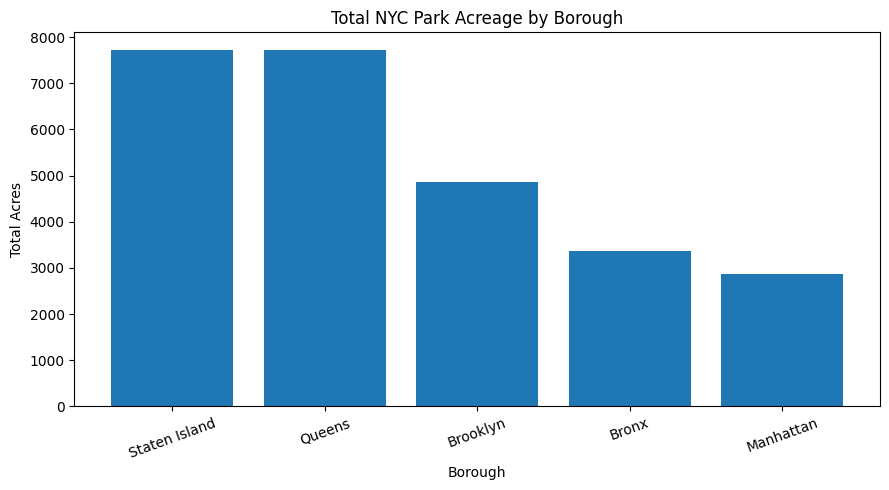

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    acres_by_borough["BOROUGH"],
    acres_by_borough["ACRES"]
)

plt.title("Total NYC Park Acreage by Borough")
plt.xlabel("Borough")
plt.ylabel("Total Acres")
plt.xticks(rotation=20)
plt.tight_layout()

acreage_chart_path = os.path.join(
    chart_folder,
    "park_acres_by_borough.png"
)

plt.savefig(
    acreage_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Chart: top park categories

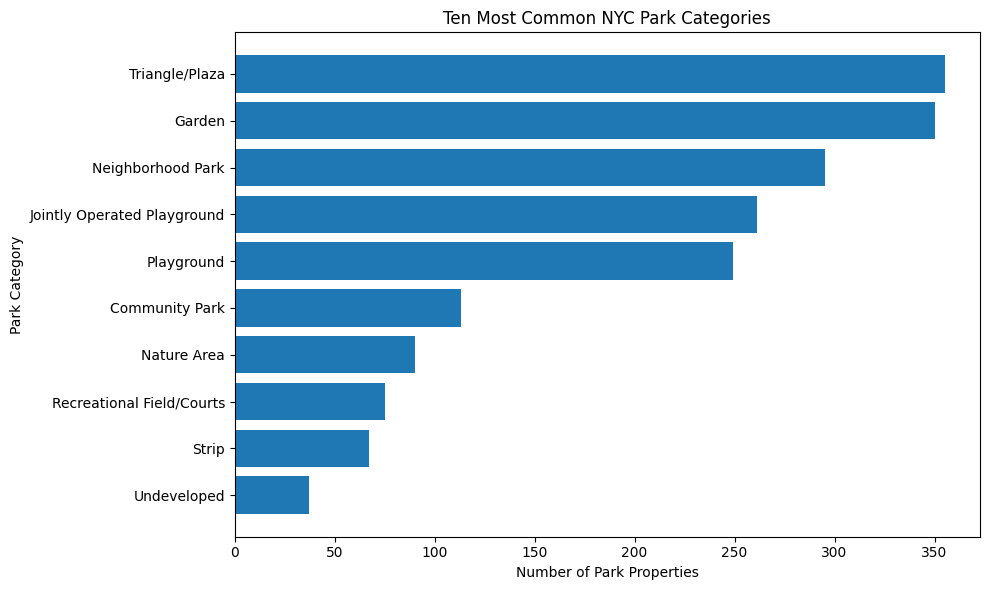

In [17]:
top_categories = park_categories.head(10).sort_values(
    "NUMBER_OF_PARKS"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["TYPECATEGORY"],
    top_categories["NUMBER_OF_PARKS"]
)

plt.title("Ten Most Common NYC Park Categories")
plt.xlabel("Number of Park Properties")
plt.ylabel("Park Category")
plt.tight_layout()

category_chart_path = os.path.join(
    chart_folder,
    "top_park_categories.png"
)

plt.savefig(
    category_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

map data

In [18]:
map_gdf = gdf[
    [
        "GISPROPNUM",
        "PARK_NAME",
        "BOROUGH",
        "ADDRESS",
        "LOCATION",
        "ACRES",
        "TYPECATEGORY",
        "SUBCATEGORY",
        "WATERFRONT",
        "ZIPCODE",
        "COMMUNITYBOARD",
        "COUNCILDISTRICT",
        "GEOMETRY"
    ]
].copy()

map_gdf = map_gdf.set_geometry("GEOMETRY")

# Simplify polygons while preserving their general shape
map_gdf["GEOMETRY"] = map_gdf.geometry.simplify(
    tolerance=0.00002,
    preserve_topology=True
)

# Replace missing values for display
display_columns = [
    "ADDRESS",
    "LOCATION",
    "TYPECATEGORY",
    "SUBCATEGORY",
    "ZIPCODE",
    "COMMUNITYBOARD",
    "COUNCILDISTRICT"
]

for column in display_columns:
    map_gdf[column] = map_gdf[column].fillna("Not available")

map_gdf["ACRES_DISPLAY"] = map_gdf["ACRES"].apply(
    lambda value: f"{value:,.2f}" if pd.notna(value)
    else "Not available"
)

map_gdf["WATERFRONT_DISPLAY"] = map_gdf["WATERFRONT"].map({
    True: "Yes",
    False: "No"
}).fillna("Not available")

Create the map

In [19]:
nyc_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=10,
    tiles="CartoDB positron",
    control_scale=True
)

# Add another map style
folium.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap"
).add_to(nyc_map)

# Add fullscreen option
Fullscreen(
    position="topright",
    title="Open full screen",
    title_cancel="Exit full screen"
).add_to(nyc_map)

# Add mini map
MiniMap(
    toggle_display=True
).add_to(nyc_map)

Add borough layers

In [20]:
boroughs = [
    "Manhattan",
    "Brooklyn",
    "Queens",
    "Bronx",
    "Staten Island"
]

for borough in boroughs:

    borough_data = map_gdf[
        map_gdf["BOROUGH"] == borough
    ].copy()

    if borough_data.empty:
        continue

    borough_layer = folium.FeatureGroup(
        name=borough,
        show=True
    )

    folium.GeoJson(
        data=json.loads(borough_data.to_json()),
        name=borough,
        style_function=lambda feature: {
            "fillOpacity": 0.45,
            "weight": 1,
            "opacity": 0.8
        },
        highlight_function=lambda feature: {
            "fillOpacity": 0.75,
            "weight": 3
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[
                "PARK_NAME",
                "BOROUGH",
                "TYPECATEGORY",
                "ACRES_DISPLAY"
            ],
            aliases=[
                "Park:",
                "Borough:",
                "Category:",
                "Acres:"
            ],
            sticky=False,
            localize=True
        ),
        popup=folium.GeoJsonPopup(
            fields=[
                "PARK_NAME",
                "GISPROPNUM",
                "BOROUGH",
                "ADDRESS",
                "LOCATION",
                "TYPECATEGORY",
                "SUBCATEGORY",
                "ACRES_DISPLAY",
                "WATERFRONT_DISPLAY",
                "ZIPCODE",
                "COMMUNITYBOARD",
                "COUNCILDISTRICT"
            ],
            aliases=[
                "Park:",
                "Property ID:",
                "Borough:",
                "Address:",
                "Location:",
                "Category:",
                "Subcategory:",
                "Acres:",
                "Waterfront:",
                "ZIP Code:",
                "Community Board:",
                "Council District:"
            ],
            localize=True,
            labels=True
        )
    ).add_to(borough_layer)

    borough_layer.add_to(nyc_map)

Add map controls and title

In [21]:
folium.LayerControl(
    collapsed=False
).add_to(nyc_map)

title_html = """
<div style="
    position: fixed;
    top: 10px;
    left: 50%;
    transform: translateX(-50%);
    z-index: 9999;
    background-color: white;
    padding: 10px 18px;
    border: 2px solid #555;
    border-radius: 6px;
    font-size: 20px;
    font-weight: bold;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">
NYC Parks Explorer
</div>
"""

nyc_map.get_root().html.add_child(
    folium.Element(title_html)
)

Save and display the map

In [22]:
map_path = os.path.join(
    map_folder,
    "nyc_parks_interactive_map.html"
)

nyc_map.save(map_path)

print("Interactive map saved at:")
print(map_path)

nyc_map

Interactive map saved at:
/content/nyc_parks_project/map/nyc_parks_interactive_map.html


Save the cleaned datasets

In [23]:
cleaned_csv_path = os.path.join(
    data_folder,
    "cleaned_nyc_parks.csv"
)

gdf.drop(
    columns=["MULTIPOLYGON", "GEOMETRY"],
    errors="ignore"
).to_csv(
    cleaned_csv_path,
    index=False
)

geojson_path = os.path.join(
    data_folder,
    "nyc_parks.geojson"
)

map_gdf.drop(
    columns=[
        "ACRES_DISPLAY",
        "WATERFRONT_DISPLAY"
    ],
    errors="ignore"
).to_file(
    geojson_path,
    driver="GeoJSON"
)

print("Cleaned CSV saved:", cleaned_csv_path)
print("GeoJSON saved:", geojson_path)

Cleaned CSV saved: /content/nyc_parks_project/data/cleaned_nyc_parks.csv
GeoJSON saved: /content/nyc_parks_project/data/nyc_parks.geojson


Create a data dictionary

In [24]:
data_dictionary = pd.DataFrame({
    "FIELD_NAME": [
        "GISPROPNUM",
        "PARK_NAME",
        "BOROUGH",
        "ADDRESS",
        "LOCATION",
        "ACRES",
        "TYPECATEGORY",
        "SUBCATEGORY",
        "WATERFRONT",
        "ZIPCODE",
        "COMMUNITYBOARD",
        "COUNCILDISTRICT",
        "LATITUDE",
        "LONGITUDE",
        "GEOMETRY"
    ],
    "DESCRIPTION": [
        "Unique GIS property identifier",
        "Publicly displayed name of the park",
        "New York City borough",
        "Street address of the park property",
        "Description of the park location",
        "Area of the park property in acres",
        "Main category of the park property",
        "More specific classification of the park",
        "Whether the property is located along the waterfront",
        "ZIP code associated with the property",
        "Community board district",
        "New York City Council district",
        "Latitude of the calculated park centroid",
        "Longitude of the calculated park centroid",
        "Multipolygon boundary of the park property"
    ],
    "DATA_TYPE": [
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Numeric",
        "Text",
        "Text",
        "Boolean",
        "Text",
        "Text",
        "Text",
        "Numeric",
        "Numeric",
        "Spatial geometry"
    ]
})

data_dictionary_path = os.path.join(
    data_folder,
    "data_dictionary.csv"
)

data_dictionary.to_csv(
    data_dictionary_path,
    index=False
)

display(data_dictionary)

print("Data dictionary saved:", data_dictionary_path)

,FIELD_NAME,DESCRIPTION,DATA_TYPE
0,GISPROPNUM,Unique GIS property identifier,Text
1,PARK_NAME,Publicly displayed name of the park,Text
2,BOROUGH,New York City borough,Text
3,ADDRESS,Street address of the park property,Text
4,LOCATION,Description of the park location,Text
5,ACRES,Area of the park property in acres,Numeric
6,TYPECATEGORY,Main category of the park property,Text
7,SUBCATEGORY,More specific classification of the park,Text
8,WATERFRONT,Whether the property is located along the wate...,Boolean
9,ZIPCODE,ZIP code associated with the property,Text


Data dictionary saved: /content/nyc_parks_project/data/data_dictionary.csv


Save analysis tables

In [25]:
summary_df.to_csv(
    os.path.join(data_folder, "project_summary.csv"),
    index=False
)

parks_by_borough.to_csv(
    os.path.join(data_folder, "parks_by_borough.csv"),
    index=False
)

acres_by_borough.to_csv(
    os.path.join(data_folder, "acres_by_borough.csv"),
    index=False
)

largest_parks.to_csv(
    os.path.join(data_folder, "largest_parks.csv"),
    index=False
)

park_categories.to_csv(
    os.path.join(data_folder, "park_categories.csv"),
    index=False
)

print("Analysis tables saved.")

Analysis tables saved.


readme

In [26]:
readme_text = """
# NYC Parks Explorer

## Project Overview

NYC Parks Explorer is an interactive geospatial data project built
using the NYC Parks Properties dataset. The project cleans and
structures public park data and presents park boundaries through an
interactive web map.

## Main Tasks

- Cleaned and standardized NYC Parks property records
- Removed duplicate, retired, and invalid records
- Converted WKT multipolygon data into spatial geometry
- Conducted quality checks on park names, boroughs, acreage, and geometry
- Calculated park centroids
- Analyzed park counts and total acreage by borough
- Created charts and summary tables
- Built an interactive web map with tooltips, popups, and borough layers
- Created a data dictionary and documented the workflow

## Tools

- Python
- Pandas
- GeoPandas
- Shapely
- Folium
- Matplotlib
- Google Colab

## Output Files

- Cleaned CSV dataset
- GeoJSON spatial dataset
- Interactive HTML map
- Data dictionary
- Summary tables
- Analysis charts

## Potential Improvements

- Add interactive filters for park type and acreage
- Add community gardens, plazas, and open streets
- Build a dashboard with Streamlit or JavaScript
- Improve accessibility and mobile responsiveness
"""

readme_path = os.path.join(
    output_folder,
    "README.md"
)

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README saved:", readme_path)

README saved: /content/nyc_parks_project/README.md


zip file

In [27]:
import shutil

zip_path = "/content/nyc_parks_project"

shutil.make_archive(
    zip_path,
    "zip",
    output_folder
)

print("Project ZIP created:")
print(zip_path + ".zip")

Project ZIP created:
/content/nyc_parks_project.zip


In [28]:
from google.colab import files

files.download("/content/nyc_parks_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>